In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("finance_features_ml_ready.csv")

exclude_cols = ["tic", "gvkey", "datadate"]
feature_cols = [c for c in df.columns if c not in exclude_cols]
df_num = df[feature_cols]

In [2]:
corr = df_num.corr()

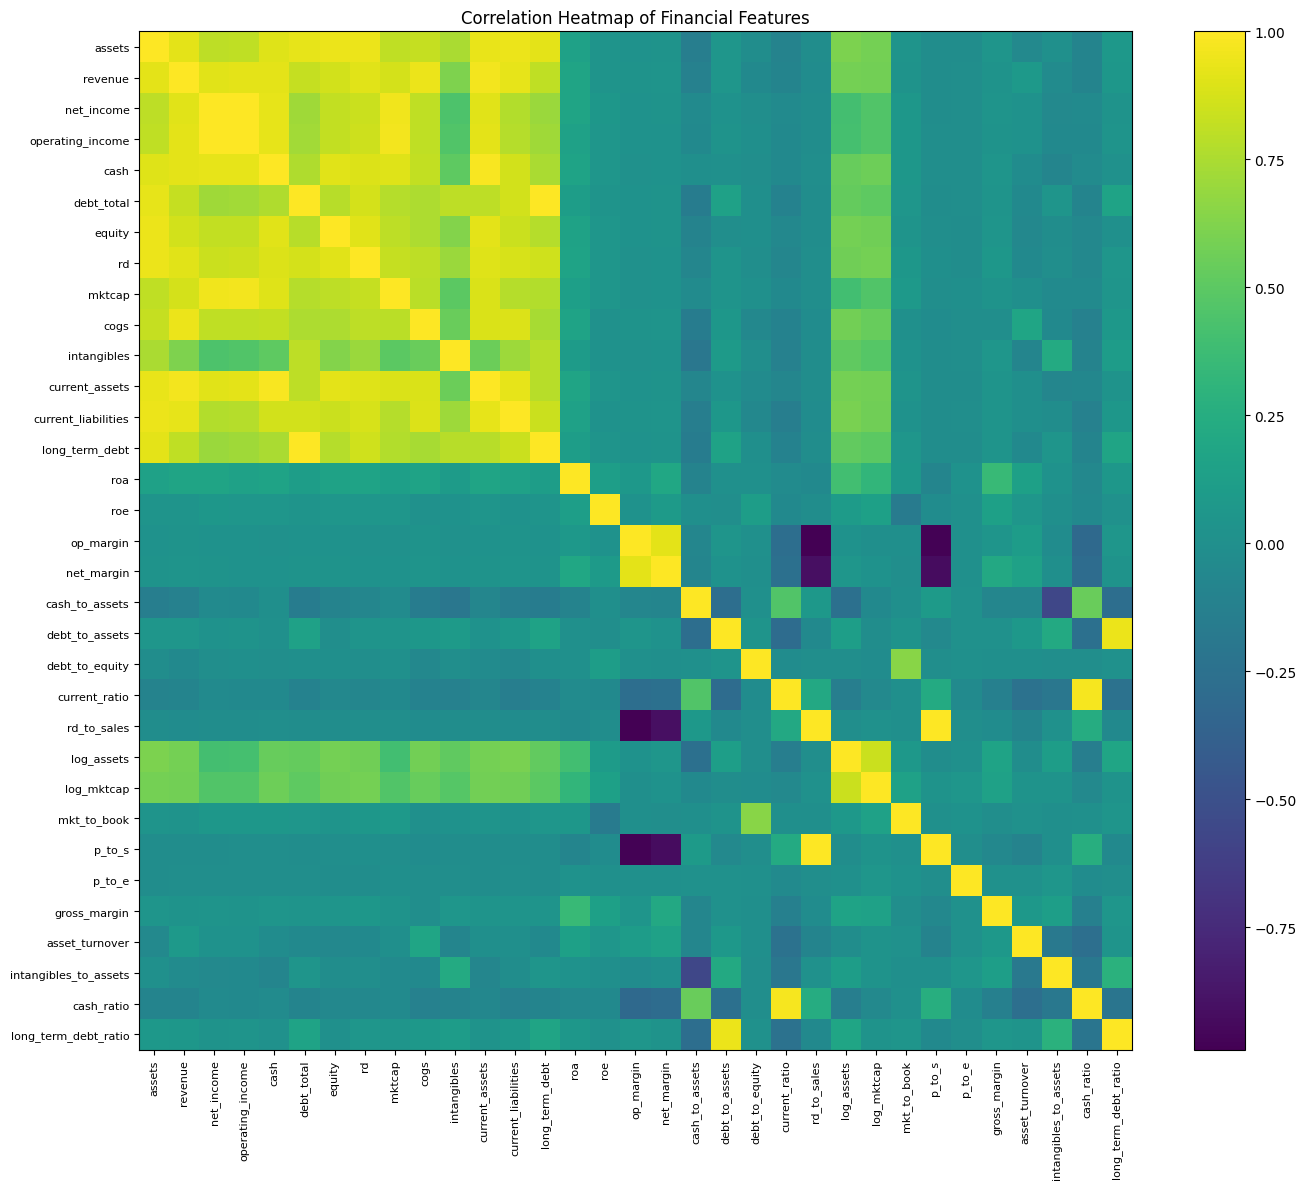

In [3]:
plt.figure(figsize=(14, 12))

im = plt.imshow(corr, aspect="auto")

plt.colorbar(im)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=8)
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=8)

plt.title("Correlation Heatmap of Financial Features")

plt.tight_layout()
plt.show()

Size-related variables (assets, revenue, market cap, equity) exhibit extremely high correlations (>0.85), indicating strong multicollinearity.

In [4]:
high_corr_pairs = []
threshold = 0.85

cols = corr.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        val = corr.iloc[i, j]
        if abs(val) > threshold:
            high_corr_pairs.append((cols[i], cols[j], val))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=["var1", "var2", "corr"])
high_corr_df = high_corr_df.sort_values("corr", key=np.abs, ascending=False)

print(high_corr_df.head(20))

                var1                  var2      corr
31        debt_total        long_term_debt  0.997938
17        net_income      operating_income  0.996904
48       rd_to_sales                p_to_s  0.993073
42         op_margin           rd_to_sales -0.989955
27              cash        current_assets  0.979681
43         op_margin                p_to_s -0.978530
47     current_ratio            cash_ratio  0.969091
22  operating_income                mktcap  0.962764
15           revenue        current_assets  0.962555
19        net_income                mktcap  0.960890
14           revenue                  cogs  0.943434
3             assets                equity  0.941032
6             assets   current_liabilities  0.940307
4             assets                    rd  0.940087
46    debt_to_assets  long_term_debt_ratio  0.939334
5             assets        current_assets  0.932347
16           revenue   current_liabilities  0.927175
21  operating_income                  cash  0.

In [6]:
# standardize
from sklearn.preprocessing import StandardScaler

X = df_num

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_fin = pd.concat([df[exclude_cols].reset_index(drop=True), X_scaled_df], axis=1)


X_fin.to_csv("X_fin_standardized.csv", index=False)
print("Done. Shape:", X_fin.shape)

Done. Shape: (403, 36)


In [8]:
# PCA
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

df = pd.read_csv("X_fin_standardized.csv")

exclude_cols = ["tic", "gvkey", "datadate"]
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols]

In [9]:
pca_full = PCA()
pca_full.fit(X)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

print(cum_var)

[0.38171931 0.51192712 0.59738706 0.64902804 0.69966249 0.74563161
 0.78718602 0.81855319 0.84900795 0.87845448 0.90307893 0.92593735
 0.94319789 0.95536884 0.96448417 0.97241436 0.9796554  0.98494967
 0.98786613 0.99041219 0.99291491 0.99492229 0.99652408 0.99780429
 0.99849573 0.99907229 0.99945715 0.99964622 0.99978155 0.99988228
 0.99994233 0.99998653 1.        ]


In [21]:
n_components = np.argmax(cum_var >= 0.80) + 1

print("Number of components (80% variance):", n_components)

Number of components (80% variance): 8


In [22]:
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

pc_cols = [f"PC{i+1}" for i in range(n_components)]
X_pca_df = pd.DataFrame(X_pca, columns=pc_cols)
X_fin_pca = pd.concat([df[exclude_cols], X_pca_df], axis=1)


X_fin_pca.to_csv("X_fin_pca.csv", index=False)
print("PCA done. Shape:", X_fin_pca.shape)

PCA done. Shape: (403, 11)


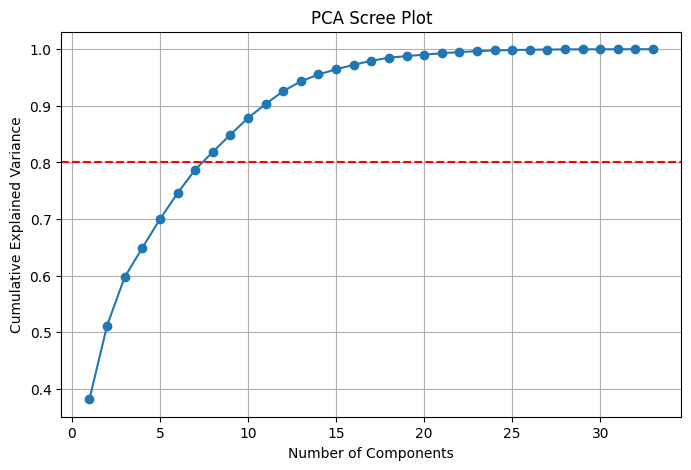

In [23]:
plt.figure(figsize=(8,5))

plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')

plt.axhline(y=0.8, color='r', linestyle='--')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot")

plt.grid()
plt.show()

In [24]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=pc_cols
)

for pc in pc_cols:
    print(f"\n{pc} top features:")
    print(loadings[pc].sort_values(key=np.abs, ascending=False).head(10))


PC1 top features:
revenue                0.272990
assets                 0.272795
current_assets         0.272082
rd                     0.267607
current_liabilities    0.264582
cash                   0.264423
equity                 0.259397
operating_income       0.254035
debt_total             0.253723
mktcap                 0.251965
Name: PC1, dtype: float64

PC2 top features:
op_margin               0.438843
p_to_s                 -0.435300
rd_to_sales            -0.429865
net_margin              0.428953
cash_ratio             -0.282176
current_ratio          -0.266686
cash_to_assets         -0.165802
debt_to_assets          0.123863
long_term_debt_ratio    0.120130
asset_turnover          0.110543
Name: PC2, dtype: float64

PC3 top features:
debt_to_assets           0.384183
long_term_debt_ratio     0.384139
cash_to_assets          -0.377098
intangibles_to_assets    0.333722
current_ratio           -0.305432
cash_ratio              -0.299946
rd_to_sales              0.233756
p_t

In [25]:
# FA
from sklearn.decomposition import FactorAnalysis
import pandas as pd

df = pd.read_csv("X_fin_standardized.csv")

exclude_cols = ["tic", "gvkey", "datadate"]
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols]

In [26]:
n_factors = 4
fa = FactorAnalysis(n_components=n_factors, random_state=42)

X_fa = fa.fit_transform(X)


fa_cols = [f"Factor{i+1}" for i in range(n_factors)]
X_fa_df = pd.DataFrame(X_fa, columns=fa_cols)
X_fin_fa = pd.concat([df[exclude_cols], X_fa_df], axis=1)


X_fin_fa.to_csv("X_fin_fa.csv", index=False)
print("FA done:", X_fin_fa.shape)

FA done: (403, 7)


In [27]:
loadings = pd.DataFrame(
    fa.components_.T,
    index=feature_cols,
    columns=fa_cols)

for f in fa_cols:
    print(f"\n{f} top features:")
    print(loadings[f].sort_values(key=abs, ascending=False).head(10))



Factor1 top features:
rd_to_sales             0.999802
p_to_s                  0.993223
op_margin              -0.990969
net_margin             -0.913083
cash_ratio              0.254233
current_ratio           0.225977
asset_turnover         -0.098229
cash_to_assets          0.083086
roa                    -0.050525
long_term_debt_ratio   -0.047431
Name: Factor1, dtype: float64

Factor2 top features:
operating_income       0.979087
net_income             0.975132
current_assets         0.963076
revenue                0.959099
cash                   0.958352
mktcap                 0.952618
rd                     0.917357
assets                 0.909378
equity                 0.895589
current_liabilities    0.869435
Name: Factor2, dtype: float64

Factor3 top features:
cash_ratio               0.961833
current_ratio            0.940049
cash_to_assets           0.539823
debt_to_assets          -0.254926
asset_turnover          -0.239396
long_term_debt_ratio    -0.212314
intangibles_to_as

In [29]:
# descriptive stats
df = pd.read_csv("finance_features_ml_ready.csv")
exclude_cols = ["tic", "gvkey", "datadate"]
feature_cols = [c for c in df.columns if c not in exclude_cols]

desc = df[feature_cols].describe().T

desc["missing_rate"] = df[feature_cols].isna().mean()

desc.to_csv("finance_descriptive_stats.csv")
print(desc.head())

                  count         mean           std         min       25%  \
assets            403.0  9620.911571  29580.333739   27.381382  608.3120   
revenue           403.0  1496.982692   4614.588940    0.605552   89.8550   
net_income        403.0   378.707284   2211.894247 -366.733418  -14.3250   
operating_income  403.0   442.947973   2510.218180 -207.990457   -7.2375   
cash              403.0  2043.317851   6654.017483    4.572776  134.8635   

                        50%        75%            max  missing_rate  
assets            1529.8875  5588.1685  203985.348544           0.0  
revenue            228.0765   760.6545   34871.602733           0.0  
net_income           7.8535    63.5800   19127.606028           0.0  
operating_income    11.3725    79.8290   21673.972791           0.0  
cash               396.3540  1224.5000   53470.768800           0.0  
